#### Instructions
###### Follow the instructions given in comments prefixed with ## and write your code below that.
###### Also fill the partial code in given blanks. 
###### Don't make any changes to the rest part of the codes

### Answer the questions given at the end of this notebook within your report.

### You would need to submit your GitHub repository link. Refer to the PDF document for the instructions and details.





In [24]:
import cv2 as cv2 ## import cv2
import numpy as np ## import numpy
import matplotlib as matplotlib ## import matplotlib
import matplotlib.pyplot as plt ## import matplotlib pyplot
from sklearn.cluster import KMeans ## import KMeans cluster from sklearn
from scipy.spatial import distance ## import distance from scipy.spatial
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

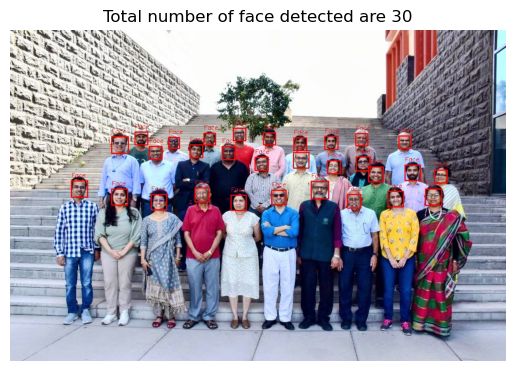

In [32]:
## Reading the image plaksha_Faculty.jpg
src = cv2.imread("Plaksha_Faculty.jpg") 
 
## Convert the image to grayscale
gray_img = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
  
# Loading the required haar-cascade xml classifier file
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Applying the face detection method on the grayscale image. 
## Change the parameters for better detection of faces in your case.
faces_rect = face_cascade.detectMultiScale(gray_img, 1.05, 4, minSize=(25,25), maxSize=(50,50))
 
# Define the text and font parameters
text = "Face" ## The text you want to write
font = cv2.FONT_HERSHEY_SIMPLEX  ## Font type
font_scale = 0.5 ## Font scale factor
font_color = (0,0,255) ## Text color in BGR format (here, it's red)
font_thickness = 1  ## Thickness of the text

  
# Iterating through rectangles of detected faces
for (x, y, w, h) in faces_rect:
    cv2.rectangle(src, (x, y), (x+w, y+h), (0, 0, 255), 2)
    # Use cv2.putText to add the text to the image, Use text, font, font_scale, font_color, font_thickness here
    cv2.putText(src, text, (x, y-10), font, font_scale, font_color, font_thickness)
    
## Display the image and window title should be "Total number of face detected are #"  

window_title = f"Total number of face detected are {len(faces_rect)}"
cv2.imshow(window_title, src)
#Save image
cv2.imwrite("output_faces.jpg", src)
cv2.waitKey(0)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Displaying the output image
img = cv2.imread("output_faces.jpg")  
output_faces_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(output_faces_img)
plt.title(f"Total number of face detected are {len(faces_rect)}")
plt.axis("off")
plt.show()

Faces detected: 30
Hue_saturation shape: (30, 2)


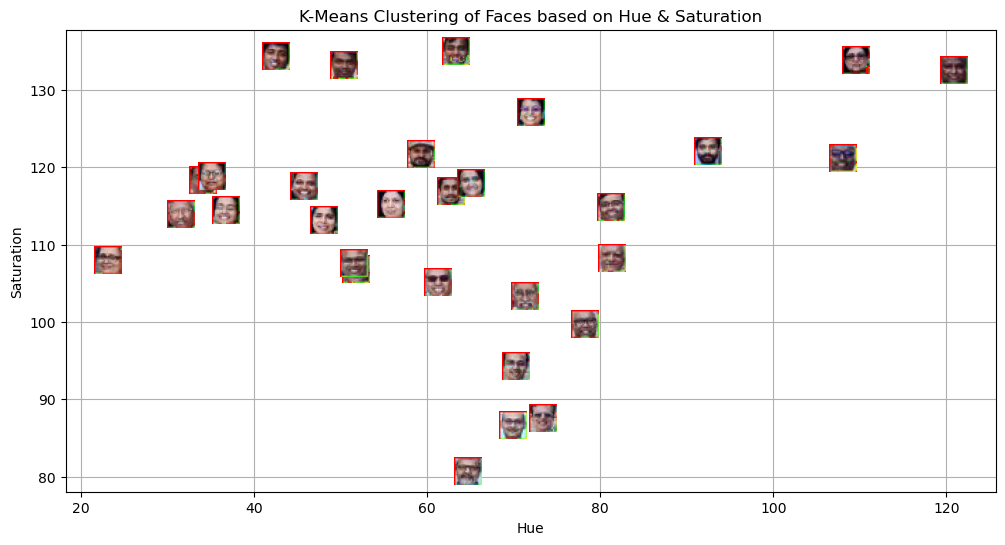

In [26]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Extract face region features (Hue and Saturation)
img_hsv = cv2.cvtColor(src, cv2.COLOR_BGR2HSV) ## call the img and convert it from BGR to HSV and store in img_hsv
hue_saturation = []
face_images = []  # To store detected face images

for (x, y, w, h) in faces_rect:
    face = img_hsv[y:y + h, x:x + w]
    hue = np.mean(face[:, :, 0])
    saturation = np.mean(face[:, :, 1])
    hue_saturation.append((hue, saturation))
    face_images.append(face)

hue_saturation = np.array(hue_saturation)

## Perform k-Means clustering on hue_saturation and store in kmeans
kmeans = KMeans(n_clusters=2, random_state=42)
print("Faces detected:", len(faces_rect))
print("Hue_saturation shape:", hue_saturation.shape)

kmeans.fit(hue_saturation)
# centroids = kmeans.cluster_centers_
# labels = kmeans.labels_

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x,y,w,h ) in enumerate(faces_rect):
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1])
    
plt.xlabel("Hue") ## Put x label
plt.ylabel("Saturation") ## Put y label
plt.title("K-Means Clustering of Faces based on Hue & Saturation") ## Put title
plt.grid(True) ## Put grid
plt.show() ## show the plot

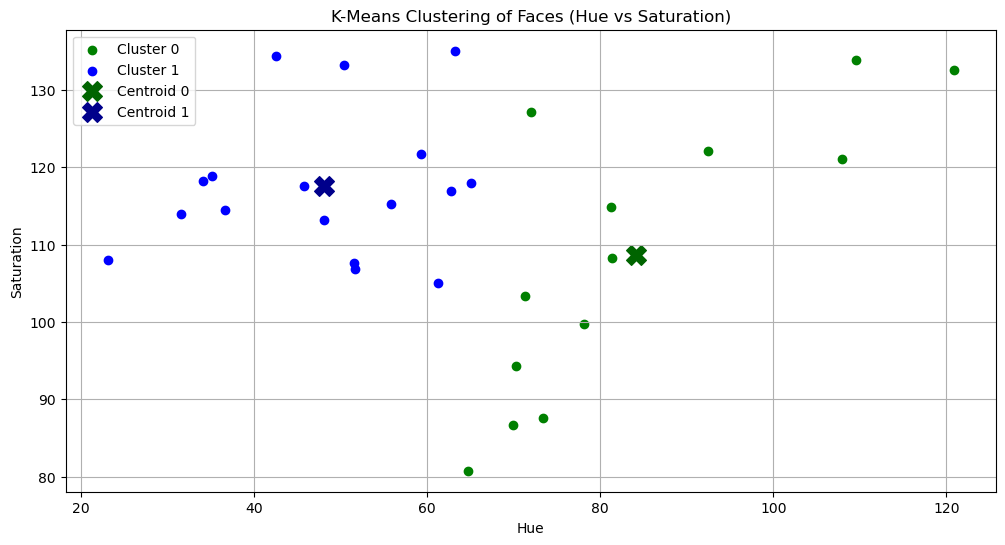

In [27]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))


cluster_0_points = np.array(cluster_0_points)
# Plot points for cluster 0 in green
plt.scatter(cluster_0_points[:, 0], cluster_0_points[:, 1], color='green', label='Cluster 0')

cluster_1_points = np.array(cluster_1_points)
# Plot points for cluster 1 in blue
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1], color='blue', label='Cluster 1')

# Calculate and plot centroids
centroid_0 = np.mean(cluster_0_points, axis=0)
centroid_1 = np.mean(cluster_1_points, axis=0)

# Plot both the centroid for cluster 0 and cluster 1 
plt.scatter(centroid_0[0],centroid_0[1],color='darkgreen',marker='X',s=200,label='Centroid 0')
plt.scatter(centroid_1[0],centroid_1[1],color='darkblue',marker='X',s=200,label='Centroid 1')

plt.xlabel("Hue") ## Put x label
plt.ylabel("Saturation") ## Put y label
plt.title("K-Means Clustering of Faces (Hue vs Saturation)") ## Put title
plt.legend() ## Add a legend
plt.grid(True) ## Add grid
plt.show() ## Show the plot


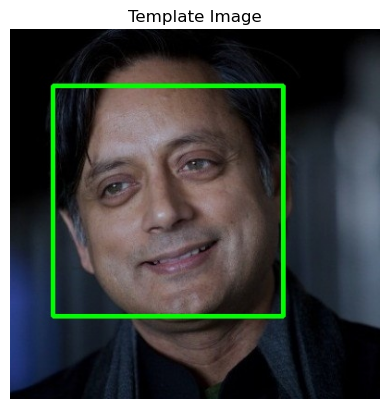

In [33]:
## Read the class of the template image 'Dr_Shashi_Tharoor.jpg' using cv2 and store it in template_img
template_img = cv2.imread("Dr_Shashi_Tharoor.jpg")
# Detect face  in the template image after converting it to gray and store it in template_faces
gray_template = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
template_faces = face_cascade.detectMultiScale(gray_template, 1.3, 5)
# Draw rectangles around the detected faces
for (x, y, w, h) in template_faces:
    cv2.rectangle(template_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
cv2.imshow("Template Face Detection", template_img)
#Save image
cv2.imwrite("output_template.jpg", template_img)
cv2.waitKey(0)
cv2.destroyAllWindows()     

#Display image
img = cv2.imread("output_template.jpg")  
output_template_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(output_template_img)
plt.title(f"Template Image")
plt.axis("off")
plt.show()

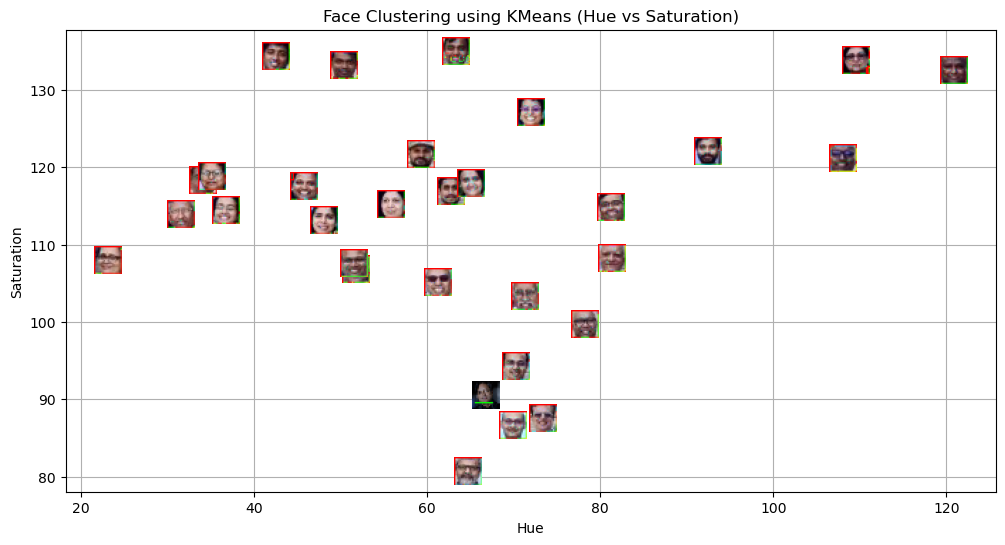

In [ ]:
# Convert the template image to HSV color space and store it in template_hsv
template_hsv = cv2.cvtColor(template_img, cv2.COLOR_BGR2HSV)

# Extract hue and saturation features from the template image as we did it for detected faces.
template_hue = np.mean(template_hsv[:, :, 0])
template_saturation = np.mean(template_hsv[:, :, 1])

# Predict the cluster label for the template image and store it in template_label
template_label = kmeans.predict([[template_hue, template_saturation]])[0]

# Create a figure and axis for visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers (similar to previous code)
for i, (x, y, w, h) in enumerate(faces_rect):
    color = 'red' if kmeans.labels_[i] == 0 else 'blue'
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1], 'o', markersize=5, color=color)

# Plot the template image in the respective cluster
if template_label == 0:
    color = 'red'
else:
    color = 'blue'
im = OffsetImage(cv2.cvtColor(cv2.resize(template_img, (20, 20)), cv2.COLOR_BGR2RGB))
ab = AnnotationBbox(im, (template_hue, template_saturation), frameon=False, pad=0)
ax.add_artist(ab)

ax.set_xlabel("Hue") ## Put x label
ax.set_ylabel("Saturation") ## Put y label
ax.set_title("Face Clustering using KMeans (Hue vs Saturation)") ## Put title
ax.grid(True) ## Add grid
plt.show() ## show plot

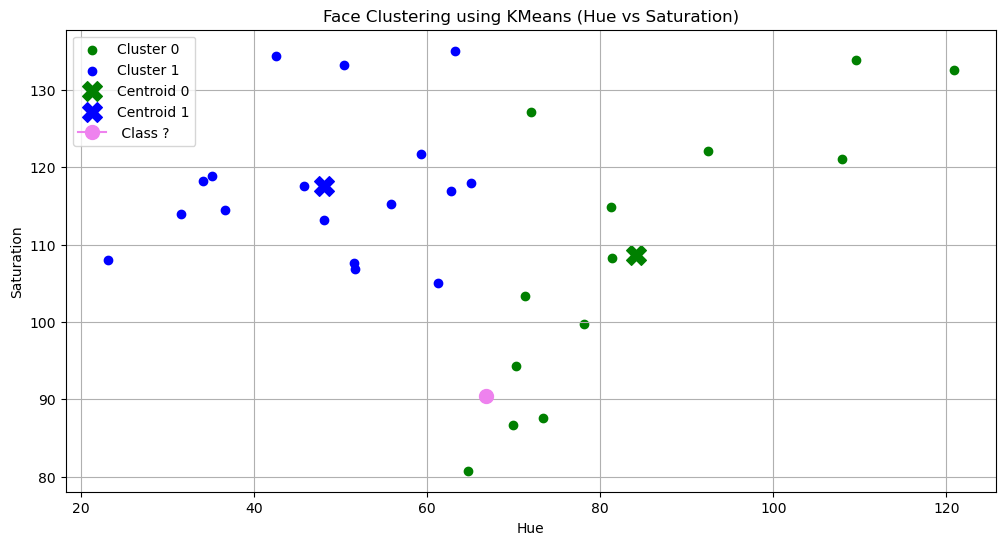

In [ ]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Plot points for cluster 0 in green
cluster_0_points = np.array(cluster_0_points)
plt.scatter(cluster_0_points[:, 0], cluster_0_points[:, 1], 
            c='green', label='Cluster 0')


# Plot points for cluster 1 in blue
cluster_1_points = np.array(cluster_1_points)
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1], 
            c='blue', label='Cluster 1')


# Calculate and plot centroids for both the clusters
centroid_0 = kmeans.cluster_centers_[0]
centroid_1 = kmeans.cluster_centers_[1]

plt.scatter(centroid_0[0], centroid_0[1], c='green', marker='X', s=200, label='Centroid 0') ## plot for centroid 0
plt.scatter(centroid_1[0], centroid_1[1], c='blue', marker='X', s=200, label='Centroid 1')  ## plot for centroid 1
plt.plot(template_hue, template_saturation, marker='o', c= 'violet',markersize= 10, label=' Class ?' )

## Put x label
## Put y label
## Put title
## Add a legend
## Add grid
## show the plot

plt.xlabel("Hue") 
plt.ylabel("Saturation")
plt.title("Face Clustering using KMeans (Hue vs Saturation)")
plt.legend()
plt.grid(True)
plt.show()

 ## End of the lab 5 ##

## Report:
## Answer the following questions within your report:


#### 1. What are the common distance metrics used in distance-based classification algorithms? 

Some widely used distance metrics are:
- Euclidean Distance (L2 norm)
- Manhattan Distance (L1 norm)
- Minkowski Distance
- Mahalanobis Distance
- Cosine Distance
- Chebyshev Distance
- Hamming Distance

These are used in algorithms like: K-Nearest Neighbors (KNN), K-Means Clustering, DBSCAN etc


#### 2. What are some real-world applications of distance-based classification algorithms? 

Distance-based methods are used in:
- Customer Behavior Prediction
- Document Classification
- Spam Filtering
- Image Classification
- Face Recognition
- Speech Recognition
Basically, anytime similarity matters, distance-based methods can be applied.


#### 3. Explain various distance metrics. 

Note: here xi and yi represent two vectors with features (x1,x2...,xn) and (y1,y2....yn)
1. Euclidean Distance: Shortest straight-line distance between two points.
𝑑(𝑥,𝑦) = (∑(𝑥𝑖− 𝑦𝑖)^2)^1/2 
Most commonly used, Sensitive to scale, Does NOT consider correlation between features

2. Manhattan Distance: Also called Taxicab distance.
𝑑(𝑥,𝑦) = ∑∣𝑥𝑖 − 𝑦𝑖∣
Works better in high dimensions, More robust than Euclidean in sparse data

3. Minkowski Distance: Generalized distance metric.
𝑑(𝑥,𝑦) = ( ∑∣𝑥𝑖 − 𝑦𝑖∣^p ) ^1/𝑝
p = 1 → Manhattan
p = 2 → Euclidean
p → ∞ → Chebyshev

4. Mahalanobis Distance: Measures distance from a distribution.
𝑑(𝑥)= (𝑥− 𝜇)𝑇 𝑆^−1 (𝑥 − 𝜇)
Where: μ = mean, S = covariance matrix
Advantages: Scale invariant, Considers correlation, Good for outlier detection

5. Cosine Distance: Measures angle between vectors.
Cosine similarity = 𝑥⋅𝑦/∣𝑥∣∣𝑦∣
Cosine similarity = ∣∣x∣∣∣∣y∣∣ x⋅y
Used in: Document similarity, Recommender systems, NLP tasks (When Magnitude doesn’t matter ; orientation matters).

6. Chebyshev Distance: Maximum absolute difference along any coordinate.
𝑑(𝑥,𝑦) = max ∣𝑥𝑖 − 𝑦𝑖∣
Used in: Chess movement, Manufacturing systems

7. Hamming Distance: Number of differing positions between two strings.
Used in: Error detection, Digital communication etc


#### 4. What is the role of cross validation in model performance? 


Cross-validation helps evaluate how well a model generalizes. It: 
- Prevents overfitting
- Helps choose best K in KNN
- Provides reliable performance estimate

Example (KNN): We:
- Split data into training + validation
- Try different values of K
- Compute validation accuracy
- Select K with lowest validation error

This ensures the model performs well on unseen data.

#### 5. Explain variance and bias in terms of KNN? 

Low K (K = 1)
- Decision boundary very complex
- Very sensitive to noise
- Model memorizes training data
- High Variance, Low Bias
leads to Overfitting

High K (K = 50)
- Very smooth boundary
- Ignores small patterns
- May predict majority class
- High Bias, Low Variance
leads to Underfitting

Trade-off: 
Small K leads to High Variance
Large K leads to High Bias

We choose optimal K using cross-validation.